In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import numpy as np
import cv2
import matplotlib.pyplot as plt
from torchvision.io import read_image

from tqdm import tqdm
from einops import rearrange, repeat
from omegaconf import OmegaConf
from functools import partial

# diffusers
import requests
from io import BytesIO
import diffusers
from diffusers import DDIMScheduler
from diffusers import StableDiffusionInpaintPipeline

from triag.diffuser_utils import McaPipeline_Replace, LocalBlend
from triag.mca_utils import regiter_attention_editor_diffusers
from triag.mca_p2p import McaControlReplace
from triag.ptp_utils import MVTecBankSimple, get_equalizer, expand_mask_tensor

from torchvision.utils import save_image
from torchvision.io import read_image
from torchvision.ops import box_convert
import torch.nn.functional as F
import torchvision.transforms as T
import torchvision.transforms.functional as TF
from pytorch_lightning import seed_everything

import PIL
from PIL import Image, ImageDraw, ImageFont
from torchvision import transforms

import argparse
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

### load stable diffusion

In [2]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
model_path = '/data1/Shared/Models/stable-diffusion-v1-5'
scheduler = DDIMScheduler(beta_start=0.00085, beta_end=0.012, beta_schedule="scaled_linear", clip_sample=False, set_alpha_to_one=False)
sd_model = McaPipeline_Replace.from_pretrained(model_path, scheduler=scheduler).to(device)
tokenizer = sd_model.tokenizer

Loading pipeline components...: 100%|██████████| 7/7 [00:00<00:00, 12.08it/s]


## generate condition and source

DDIM Inversion: 100%|██████████| 50/50 [00:03<00:00, 15.60it/s]


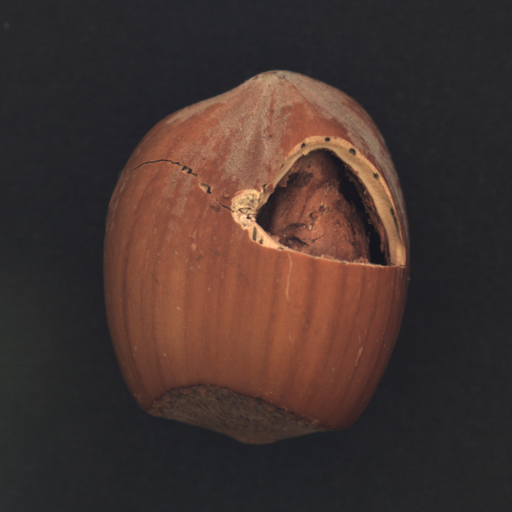

In [3]:
def load_image_k(image_path, device):
    image = read_image(image_path)
    image = image[:3].unsqueeze_(0).float() / 127.5 - 1.  # [-1, 1]
    image = F.interpolate(image, (512, 512))
    image = image.to(device)
    return image

source_prompt = ""
ref_prompt = ""
cls_object = "hazelnut"
anomaly_type = "crack"
target_prompt = f"a photo of a {cls_object} with a {anomaly_type}"
num_inference_steps = 50

# ref image
REF_IMAGE_PATH = "data/anomaly/000.png"
ref_mask_path = "data/anomaly/000_mask.png"

ref_image = load_image_k(REF_IMAGE_PATH, device)

# invert the source image
ref_start_code, ref_latents_list = sd_model.invert(ref_image,
                                        ref_prompt,
                                        guidance_scale=7.5,
                                        num_inference_steps=num_inference_steps,
                                        return_intermediates=True)

pil_image = transforms.ToPILImage()(read_image(REF_IMAGE_PATH))
pil_image.resize((512,512))

DDIM Inversion: 100%|██████████| 50/50 [00:03<00:00, 15.84it/s]


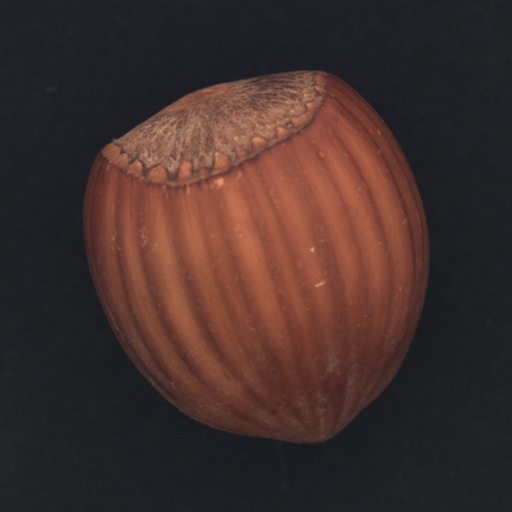

In [4]:
# normal image
SOURCE_IMAGE_PATH = "data/000.png"
source_mask_path = "./data/0.jpg"  # target anomaly mask from AnomalyDiffusion
source_image = load_image_k(SOURCE_IMAGE_PATH, device)

# results of direct synthesis
source_start_code, source_latents_list = sd_model.invert(source_image,
                                            source_prompt,
                                            guidance_scale=7.5,
                                            num_inference_steps=num_inference_steps,
                                            return_intermediates=True)

pil_image = transforms.ToPILImage()(read_image(SOURCE_IMAGE_PATH))
pil_image.resize((512,512))

# display mask and image

In [5]:
def show_overlay(img_tensor: torch.Tensor,
                 mask_tensor: torch.Tensor,
                 title: str = "",
                 mask_color=(0, 255, 0),
                 alpha: float = 0.35) -> None:
    if img_tensor.dim() == 4:
        img_tensor = img_tensor[0]
    img_np = img_tensor.detach().cpu().numpy()
    img_np = np.transpose(img_np, (1, 2, 0))        # CHW→HWC
    img_np = ((img_np + 1) * 0.5 * 255).clip(0, 255).astype(np.uint8)
    mask_np = mask_tensor.detach().cpu().float().numpy()
    if mask_np.max() > 1:
        mask_np = mask_np / 255.
    mask_np = mask_np > 0.5            # bool
    overlay = np.zeros((*mask_np.shape, 4), dtype=np.uint8)
    overlay[..., :3] = mask_color
    overlay[..., 3]  = (mask_np * alpha * 255).astype(np.uint8)
    composite = Image.alpha_composite(Image.fromarray(img_np).convert("RGBA"), Image.fromarray(overlay))
    fig, ax = plt.subplots(1, 2, figsize=(8, 4))
    ax[0].imshow(img_np);      ax[0].set_title(f"{title}"); ax[0].axis("off")
    ax[1].imshow(composite);   ax[1].set_title(f"{title} • overlay"); ax[1].axis("off")
    plt.tight_layout(); plt.show()


## load mask

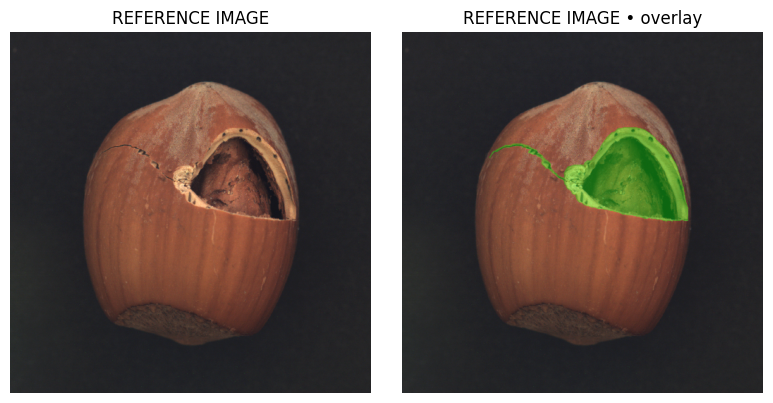

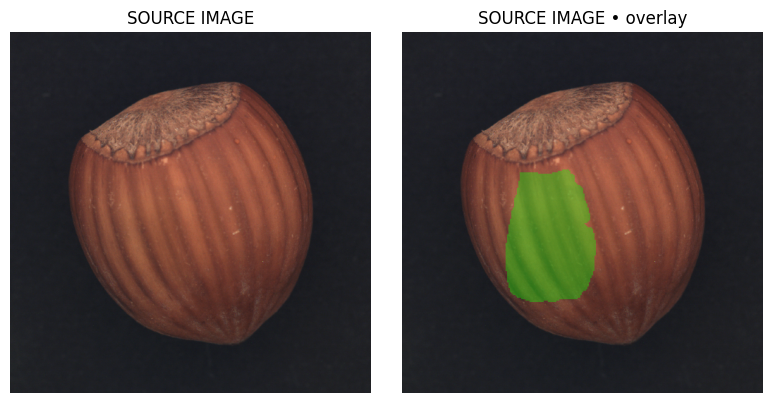

In [6]:
ref_mask = Image.open(ref_mask_path).convert("L")
source_mask = Image.open(source_mask_path).convert("L")
ref_mask = ref_mask.resize((512, 512), Image.NEAREST)
source_mask = source_mask.resize((512, 512), Image.NEAREST)
ref_mask = T.ToTensor()(ref_mask)
source_mask = T.ToTensor()(source_mask)
ref_mask = (ref_mask > 0.5).float().squeeze(0)
source_mask = (source_mask > 0.5).float().squeeze(0)
ref_mask = ref_mask.to("cuda")   # device='cuda:0'
source_mask = source_mask.to("cuda")
source_mask = expand_mask_tensor(source_mask, radius=3, iters=1)
show_overlay(ref_image, ref_mask, title = "REFERENCE IMAGE")
show_overlay(source_image, source_mask, title = "SOURCE IMAGE")

## inference the synthesized image

DAE attention re-weight timestep:  (20, 40)
TriAG at denoising steps:  [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49]
TriAG at U-Net layers:  [9, 10, 11, 12, 13, 14, 15]
input text embeddings : torch.Size([3, 77, 768])
latents shape:  torch.Size([3, 4, 64, 64])


DDIM Sampler:   0%|          | 0/50 [00:00<?, ?it/s]

DDIM Sampler: 100%|██████████| 50/50 [00:21<00:00,  2.34it/s]


latents shape:  torch.Size([3, 4, 64, 64])


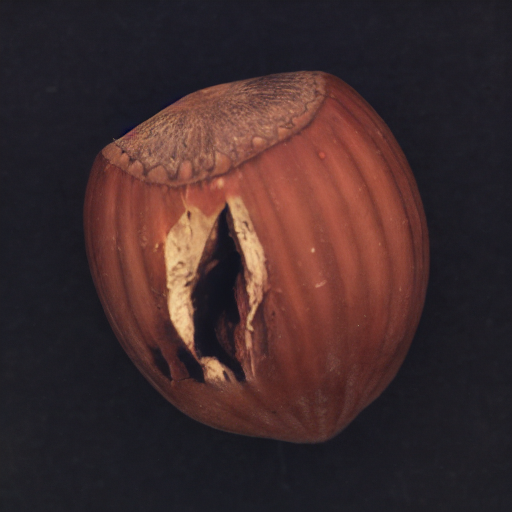

In [7]:
lbl = LocalBlend(source_mask.float())
self_replace_steps = 0.1
cross_replace_steps = 0.4, 0.8  # cross-attention upweight
START_LAYPER = 9
END_LAYPER = 16
START_STEP = 4
END_STEP = 50
prompts = ['a photo of a hazelnut with a crack', 'a photo of a hazelnut', target_prompt]
ref_start_code = ref_start_code.expand(len(prompts), -1, -1, -1)
source_start_code = source_start_code.expand(len(prompts), -1, -1, -1)

# load optimized anomaly embedding
bank = MVTecBankSimple(bank_path="./embed_bank/mvtec")
opt_embeddings = None
if bank.exists(cls_object, anomaly_type, REF_IMAGE_PATH):
    emb_cpu = bank.load(cls_object, anomaly_type, REF_IMAGE_PATH).clone().detach()
    opt_embeddings = emb_cpu.to(device=sd_model.device, dtype=sd_model.unet.dtype)

negative_prompt = (
    # --- specifically suppress the “intact / smooth” semantics ---
    # MvTec
    "intact shell, smooth surface, pristine, flawless, clean, "
    "no crack, no cut, no scratch, no squeeze, perfect condition"

    # Visa
    # "intact, flawless, pristine, perfect condition, undamaged, unbroken, "
    # "complete, smooth, clean, spotless, single, symmetrical, aligned, uniform color, pristine surface"
)

### pay 100 times more attention to the word "crack"
equalizer = get_equalizer(prompts[2], (anomaly_type,), (100,), tokenizer).to(device)
editor = McaControlReplace(prompts, tokenizer, [0,1,2,3], 
                           self_replace_steps, cross_replace_steps, 
                           equalizer, START_STEP, END_STEP, START_LAYPER, END_LAYPER, 
                           mask_s=ref_mask.float(), mask_t=source_mask.float(), 
                           attn_store_judge=False)
regiter_attention_editor_diffusers(sd_model, editor)

image_mcactrl, cross_image = sd_model(prompts,
                    latents=source_start_code,
                    num_inference_steps=num_inference_steps,
                    guidance_scale=7.5,
                    ref_intermediate_latents=[ref_latents_list, source_latents_list],
                    lbl = lbl,
                    neg_prompt = negative_prompt,
                    mask_r = ref_mask.float(),
                    mask_t = source_mask.float(),
                    return_intermediates=True,
                    opt_embeddings=opt_embeddings
                    )

pil_image = transforms.ToPILImage()(image_mcactrl[-1:].squeeze())
pil_image